## Read .nc files in $PERM and plot 

In [ ]:
import xarray as xr
import os
import dask
import h5netcdf
import numpy as np
from datetime import timedelta
import gc
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt


import sys
sys.path.append(".")
sys.path.append("/home/paaa/python_scripts/")
import my_functions as mfun

# Paths and configuration
dir_dales = "/perm/paaa/Les/Cases/Catrine"
save_dir = dir_dales
suffix = '_50km'
str_time = '2022-05-17T02'
end_time = '2022-05-19T00'

# Domain selection
xmin, xmax = 62000, 112000
ymin, ymax = 21000, 71000
xsize = xmax - xmin
ysize = ymax - ymin
dt = 3600 #s

col = ['#D04848','#6895D2','#F3B95F','#59981A']
sty = ['--','-',':']

hours_day   =[9 ,10,11,12,13,14,15,16,17] # daytime
hours_night =[21,22,23,0 ,1 ,2 ,3 ,4 ,5 ] # nighttime
# hours =[2,3,4,5,6,7,8]

vars = ['sv004','thl','u','v']
ds = {}
for var in vars:
    file = [os.path.join(dir_dales, f) for f in os.listdir(dir_dales) if var+'_flx_' in f and suffix in f and f.endswith('.nc')]
    print(file)
    dset = xr.open_mfdataset(file, combine='by_coords', engine='h5netcdf')
    ds[var] = dset
    ds[var]['up_flx_frac'] = (ds[var][f"{var}w_filtered"]/ds[var][f"{var}w_unfiltered"])
    # tendnecies
    ds[var]['up_tend']  = ds[var][f"{var}w_filtered"].differentiate('zt') * dt
    ds[var]['tot_tend'] = ds[var][f"{var}w_unfiltered"].differentiate('zt') * dt

#########################
closest_idx_9 = abs(ds['sv004']["filter"] - 9).argmin(dim="klp").values
closest_idx_05 = abs(ds['sv004']["filter"] - 0.5).argmin(dim="klp").values
closest_idx_01 = abs(ds['sv004']["filter"] - 0.1).argmin(dim="klp").values
# Select the corresponding sv004 value
co2_flx_up9km = ds['sv004']['sv004w_filtered'].isel(klp=closest_idx_9)
co2_flx_up05km = ds['sv004']['sv004w_filtered'].isel(klp=closest_idx_05)
co2_flx_up01km = ds['sv004']['sv004w_filtered'].isel(klp=closest_idx_01)
# compute tendencies
co2_tend_up9km = ds['sv004']['up_tend'].isel(klp=closest_idx_9)
co2_tend_up05km = ds['sv004']['up_tend'].isel(klp=closest_idx_05)
co2_tend_up01km = ds['sv004']['up_tend'].isel(klp=closest_idx_01)
#########################

['/perm/paaa/Les/Cases/Catrine/sv004_flx_filter_50km_z900.nc', '/perm/paaa/Les/Cases/Catrine/sv004_flx_filter_50km_z4200.nc', '/perm/paaa/Les/Cases/Catrine/sv004_flx_filter_50km_z1700.nc', '/perm/paaa/Les/Cases/Catrine/sv004_flx_filter_50km_z2200.nc', '/perm/paaa/Les/Cases/Catrine/sv004_flx_filter_50km_z600.nc', '/perm/paaa/Les/Cases/Catrine/sv004_flx_filter_50km_z3200.nc', '/perm/paaa/Les/Cases/Catrine/sv004_flx_filter_50km_z3700.nc', '/perm/paaa/Les/Cases/Catrine/sv004_flx_filter_50km_z300.nc', '/perm/paaa/Les/Cases/Catrine/sv004_flx_filter_50km_z2700.nc', '/perm/paaa/Les/Cases/Catrine/sv004_flx_filter_50km_z1200.nc']
['/perm/paaa/Les/Cases/Catrine/thl_flx_filter_50km_z900.nc', '/perm/paaa/Les/Cases/Catrine/thl_flx_filter_50km_z4200.nc', '/perm/paaa/Les/Cases/Catrine/thl_flx_filter_50km_z1700.nc', '/perm/paaa/Les/Cases/Catrine/thl_flx_filter_50km_z2200.nc', '/perm/paaa/Les/Cases/Catrine/thl_flx_filter_50km_z600.nc', '/perm/paaa/Les/Cases/Catrine/thl_flx_filter_50km_z3200.nc', '/perm/

# PLOT

Text(0.5, 1.0, 'Daytime tendencies DALES')

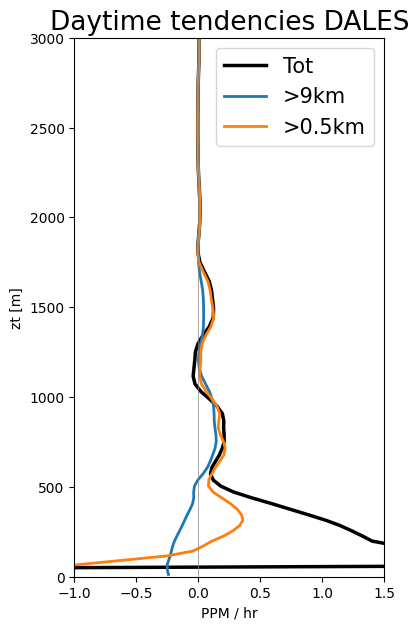

In [102]:
plt.figure(figsize=(4,7))
line_1 =co2_tend_up9km.sel(time=co2_tend_up9km['time'].dt.hour.isin(hours_day)).mean('time')  # Select hours
line_2 =co2_tend_up05km.sel(time=co2_tend_up05km['time'].dt.hour.isin(hours_day)).mean('time')  # Select hours
line_3 =ds['sv004']['tot_tend'].sel(time=ds['sv004']['time'].dt.hour.isin(hours_day)).mean('time')  # Select hours


line_3.plot(y='zt', lw=2.5, label='Tot', c='k')
line_1.plot(y='zt', lw=2, label='>9km')
line_2.plot(y='zt', lw=2, label='>0.5km')

plt.axvline(0,lw=0.5,c='grey')
plt.legend(fontsize=15)
plt.ylim([0,3000])
plt.xlim([-1,1.5])
plt.xlabel('PPM / hr')
plt.title('Daytime tendencies DALES',fontsize=19)

(0.0, 3300.0)

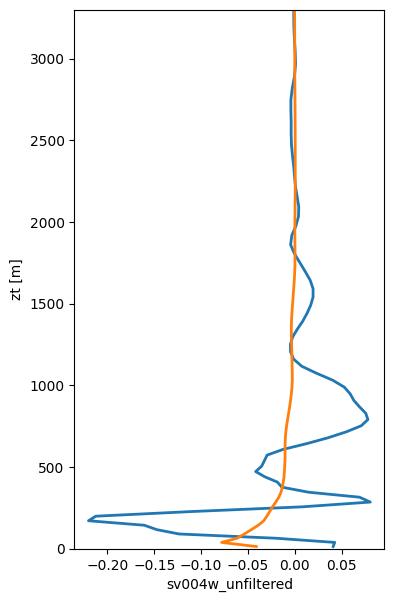

In [80]:
plt.figure(figsize=(4,7))
co2_tend_up9km.mean('time').plot(y='zt', lw=2)
ds['sv004']['sv004w_unfiltered'].mean('time').plot(y='zt', lw=2)
plt.ylim([0,3300])

Text(0.5, 1.0, ' Flux partition between [2000, 2200] m')

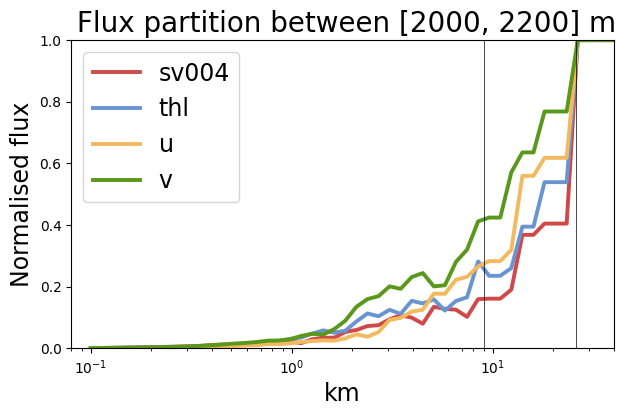

In [10]:
iz = [2000,2200]
plt.figure(figsize=(7,4))
for ide,var in enumerate(vars):
    plt.plot(ds[var].filter,(1-ds[var]['up_flx_frac'].sel(zt=slice(iz[0],iz[1])).mean('zt')).median('time'),\
                lw=2.8,c=col[ide],label=var)
plt.axvline(26,c='k',lw=0.5)
plt.axvline(9,c='k',lw=0.5)
plt.axhline(0,c='k',lw=0.5)
plt.axhline(1,c='k',lw=0.5)
plt.legend(fontsize=17)
plt.xscale('log')
plt.xlabel('km',fontsize=17)
plt.ylabel('Normalised flux',fontsize=17)
plt.ylim([0,1])
plt.xlim([0.08,40])
plt.title(f' Flux partition between {iz} m',fontsize=20)

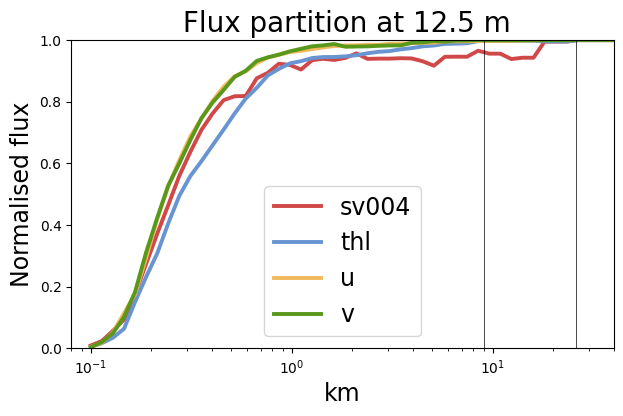

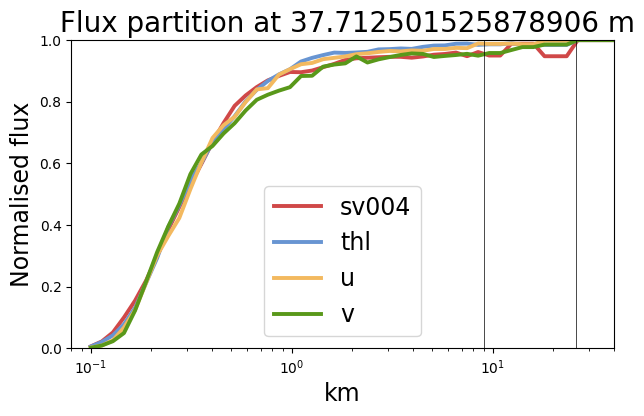

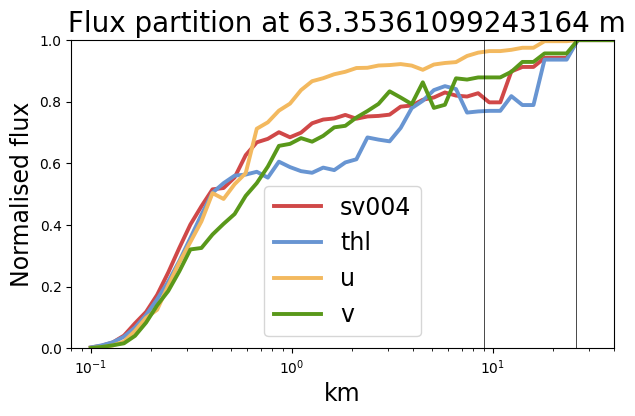

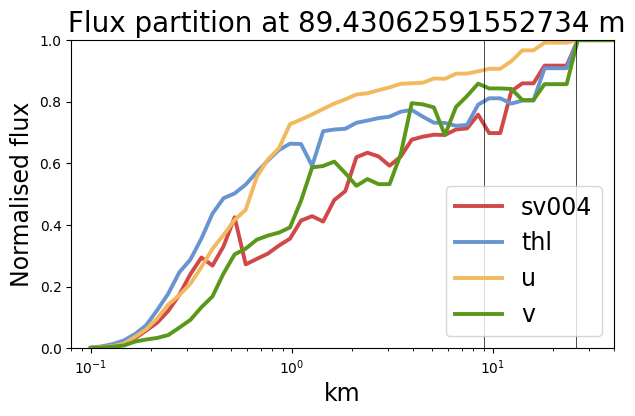

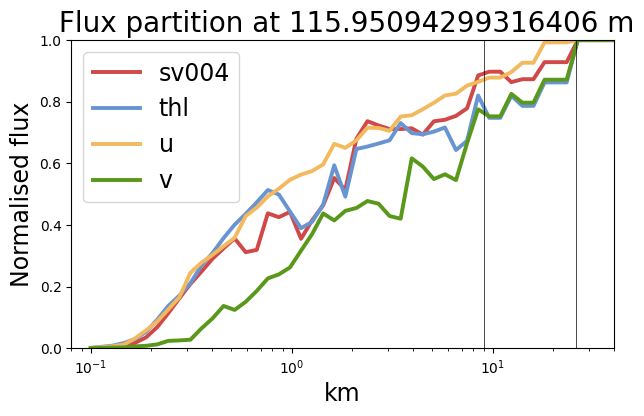

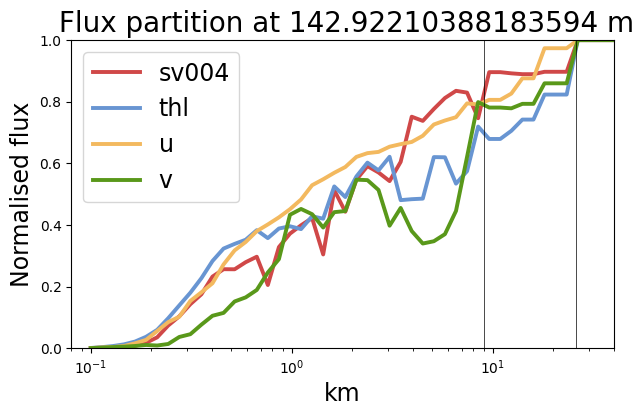

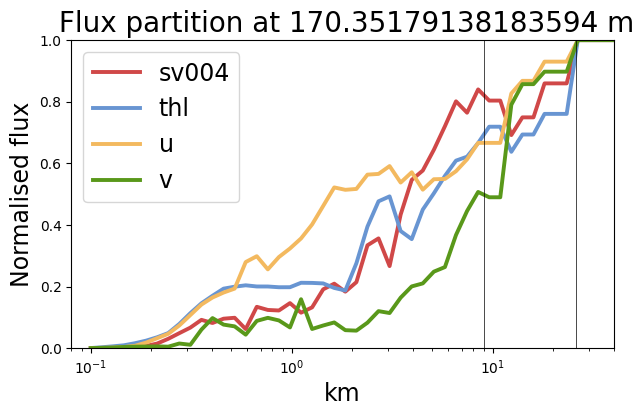

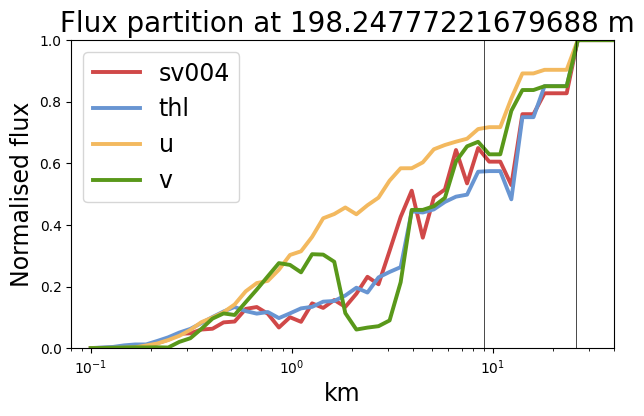

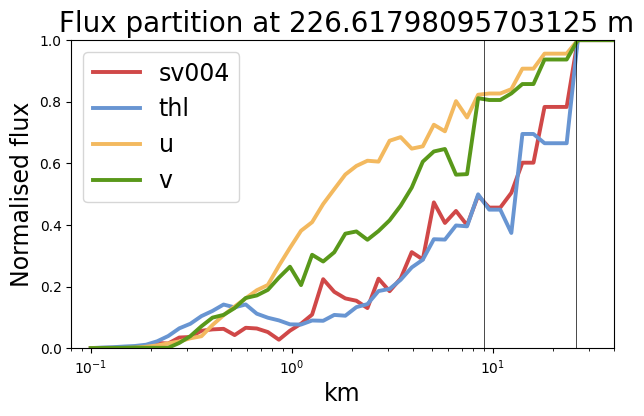

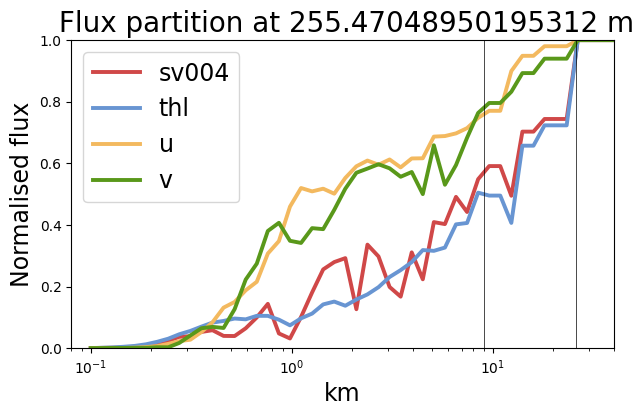

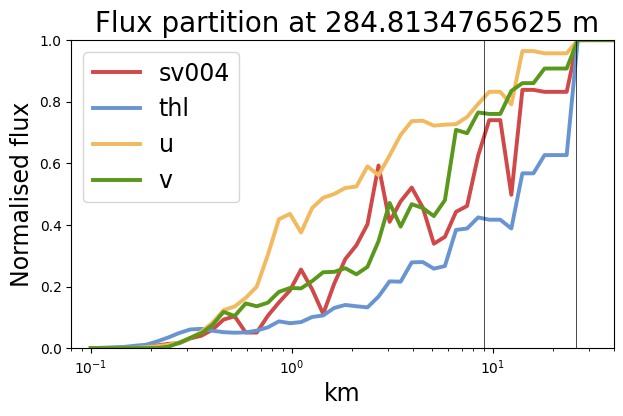

In [38]:
iz = 300
for iz in ds[var].zt.values:
    plt.figure(figsize=(7,4))
    for ide,var in enumerate(vars):
        plt.plot(ds[var].filter,(1-ds[var]['up_flx_frac'].sel(zt=iz,method='nearest')).median('time'),\
                    lw=2.8,c=col[ide],label=var)
    plt.axvline(26,c='k',lw=0.5)
    plt.axvline(9,c='k',lw=0.5)
    plt.axhline(0,c='k',lw=0.5)
    plt.axhline(1,c='k',lw=0.5)
    plt.legend(fontsize=17)
    plt.xscale('log')
    plt.xlabel('km',fontsize=17)
    plt.ylabel('Normalised flux',fontsize=17)
    plt.ylim([0,1])
    plt.xlim([0.08,40])
    plt.title(f' Flux partition at {iz} m',fontsize=20)

Text(0.5, 1.0, ' u flux at 10 m')

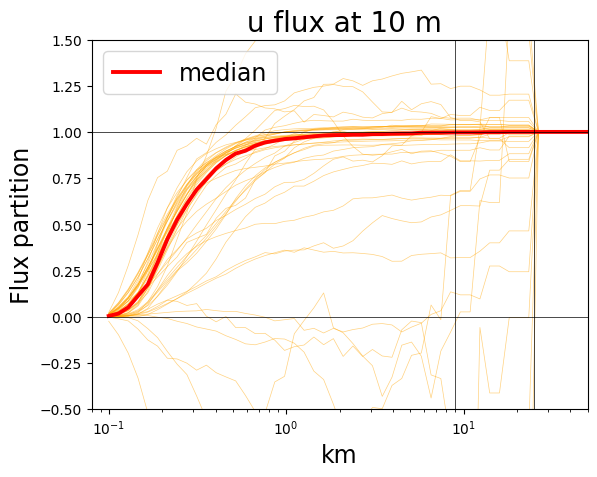

In [14]:
iz = 10
var = 'u'
plt.figure()
for i in ds[var].time:
    plt.plot(ds[var].filter,(1-ds[var]['up_flx_frac'].sel(zt=iz,method='nearest').sel(time=i)),\
                lw=0.5,c='orange',alpha=0.5)
plt.plot(ds[var].filter,(1-ds[var]['up_flx_frac'].sel(zt=iz,method='nearest')).median('time'),\
              lw=2.8,c='r',label='median')
plt.axvline(25,c='k',lw=0.5)
plt.axvline(9,c='k',lw=0.5)
plt.axhline(0,c='k',lw=0.5)
plt.axhline(1,c='k',lw=0.5)
plt.legend(fontsize=17)
plt.xscale('log')
plt.xlabel('km',fontsize=17)
plt.ylabel('Flux partition',fontsize=17)
plt.ylim([-0.5,1.5])
plt.xlim([0.08,50])
plt.title(f' {var} flux at {iz} m',fontsize=20)

# SCALE DECOMPOSITION OPTION 2

In [305]:
def load_dales_var(var_name,dir_dales):
    str_time = '2022-05-17T02'
    end_time = '2022-05-19T00'
    xmin, xmax = 62000, 112000
    ymin, ymax = 21000, 71000
    zmin, zmax = 30,40

    if not np.allclose(xmax - xmin, ymax - ymin):
        print('Domain cropped is not a square')

    files_var = [os.path.join(dir_dales, f) for f in os.listdir(dir_dales) if 'loobos_' in f and f"{var_name}_3d" in f and f.endswith('.nc')]
    dset_var = xr.open_mfdataset(files_var,
                                combine='by_coords',
                                chunks={'time': 12, 'zt': 8, 'xt': -1, 'yt': -1},
                                engine='h5netcdf'
                                )
    dset_var = dset_var.sel(xt=slice(xmin, xmax),
                            yt=slice(ymin, ymax),
                            zt=slice(zmin, zmax)
                            )
    dset_var['time'] = dset_var['time'].astype('datetime64[ns]') + np.timedelta64(2, 'D')
    dset_var = dset_var.sel(time=slice(str_time, end_time))
    return dset_var.compute()

# Load w first to compute w_p for all variables
dset_w = load_dales_var('w',dir_dales)
dset_u = load_dales_var('u',dir_dales)
dset_co2 = load_dales_var('sv004',dir_dales)
dset_thl = load_dales_var('thl',dir_dales)

w = dset_w['w']
u = dset_u['u']
co2 = dset_co2['sv004']

xt = np.radians(u.xt.data)
yt = np.radians(u.yt.data)
Nx = xt.shape[0]
Ny = yt.shape[0]
xsize = (dset_w.xt[-1] - dset_w.xt[0]).data
ysize = (dset_w.yt[-1] - dset_w.yt[0]).data
dx = xsize/Nx
dy = ysize/Ny

In [306]:
large_scale = 50 #km
klp = min(xsize,ysize)/(2*large_scale*1000) # half the number of grids after coarsening 
## Filtering away scales larger than large_scale (50 km)
mask =  mfun.create_radial_mask((dset_w.sizes["yt"], dset_w.sizes["xt"]), cutoff=klp)
var_psf = mfun.low_pass_filter(dset_w, 1-mask) # high pass filter because of 1- mask 


In [ ]:
## Crop the domain of interest
# xmin, xmax = 62000, 112000
# ymin, ymax = 21000, 71000

# dset_var = dset_var.sel(xt=slice(xmin, xmax),
#                         yt=slice(ymin, ymax),
#                         )

#### Compute fluxes using FFTs

In [192]:
what = np.fft.fft2(w.data)
uhat = np.fft.fft2(u.data)
co2hat = np.fft.fft2(co2.data)
""" To remove the mean, we set the k=0,l=0 coefficients to 0 """

what[...,0,0] = 0.
uhat[...,0,0] = 0.
co2hat[...,0,0] = 0.


uflux_hat = np.conj(what)*uhat/(Nx*My)
co2flux_hat = np.conj(what)*co2hat/(Nx*My)

### Compute fluxes by removing mean

In [193]:
wprime = w.data - w.mean(dim=['xt','yt']).data[...,np.newaxis,np.newaxis]
uprime = u.data - u.mean(dim=['xt','yt']).data[...,np.newaxis,np.newaxis]
co2prime = co2.data - co2.mean(dim=['xt','yt']).data[...,np.newaxis,np.newaxis]


ufluxes = uprime * wprime
co2fluxes = co2prime * wprime

In [194]:
total_uflux = np.sum(ufluxes,axis=(-2,-1)).mean() # sum over space and mean over time
# total_uflux = np.mean(ufluxes,axis=(-2,-1)).mean() # mean over space and mean over time

total_uflux

np.float32(-6190.2646)

In [195]:
total_hat_uflux = np.real(np.sum(uflux_hat,axis=(-2,-1))).mean() # sum over wavenumbers and mean over time
# total_hat_uflux = np.real(np.mean(uflux_hat,axis=(-2,-1))).mean() # mean over wavenumbers and mean over time

print(total_hat_uflux)

-6190.2646


### Show that they are equal

In [196]:
np.allclose(total_uflux, total_hat_uflux)

True

### Compute total wavenumber

In [ ]:

k = 2*np.pi*np.fft.fftfreq(Nx,dx)
l = 2*np.pi*np.fft.fftfreq(Ny,dy)
kk, ll = np.meshgrid(k,l)
ktot = (kk**2 + ll**2)**0.5

In [ ]:
ktot_flat = ktot.flatten()
# Get the indices that would sort ktot in ascending order
sort_indices = np.argsort(ktot_flat)

ufluxes_flat = uflux_hat.mean(axis=(0,1)).flatten()
co2fluxes_flat = co2flux_hat.mean(axis=(0,1)).flatten()


Text(0.5, 1.0, 'CO$_2$ flux')

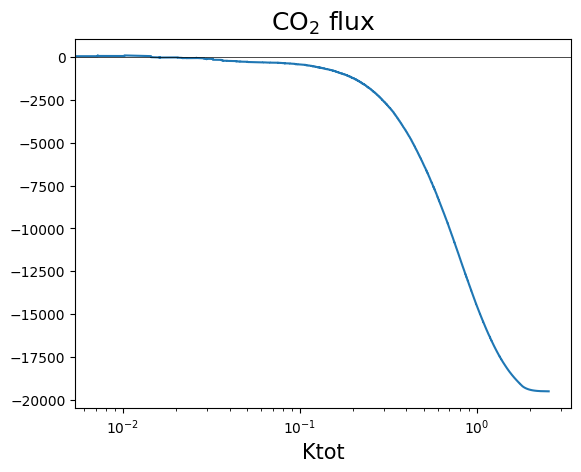

In [259]:
# import metview as mv
import matplotlib.pyplot as plt
# matplotlib ipympl
import matplotlib.pyplot as plt

plt.figure()
plt.plot(ktot_flat[sort_indices], np.cumsum(co2fluxes_flat[sort_indices])) # cumulative sum # ktot = 2pi/wavelengh 
plt.axhline(0,c='k',lw=0.5)
plt.xscale('log')
# plt.ylim([-20,20])
plt.xlabel('Ktot',fontsize=15)
plt.ylabel('',fontsize=15)
plt.title(r'CO$_2$ flux',fontsize=18)


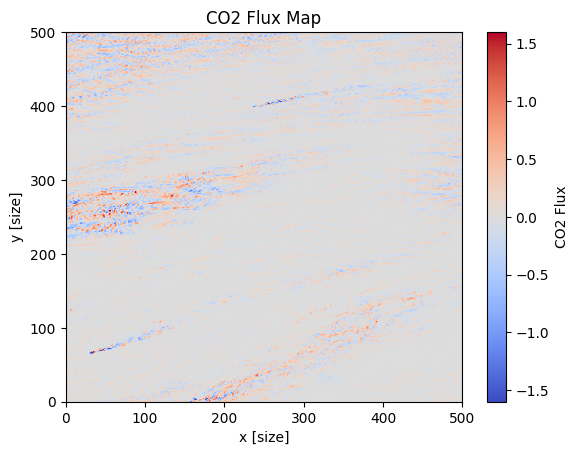

In [226]:
plt.figure()
plt.pcolormesh(co2fluxes[1,0,:,:], shading='auto',
               cmap='coolwarm',
               vmin=-1.6,
               vmax=1.6
               )
plt.colorbar(label='CO2 Flux')
plt.title('CO2 Flux Map')
plt.xlabel('x [size]')
plt.ylabel('y [size]')
plt.show()

# Option 3